# Why is our rejection rate ~16% when the MSR paper reported 46%?

Both studies look at **bug-fix PRs by the same four agents in popular (>100-star) repos**, yet:
- **MSR paper:** 3,225 fix PRs, **46.4% rejected**.
- **This dataset:** ~122,000 agent fix PRs, **~16% rejected**.

This notebook does an apples-to-apples check and finds the gap is **entirely about which PRs are labelled "fix"** —
not about project popularity, time window, or when the data was collected.

## Step 1 — Reproduce the paper exactly

The paper uses AIDev's **curated** snapshot (`pull_request.parquet`, 33,596 PRs) and AIDev's own task-type classifier
(`pr_task_type.parquet`): keep `type == 'fix'`, closed PRs, drop Codex. That gives **3,225 fix PRs, 46.4% rejected** —
matching the paper. Notice the set is **Devin- and Copilot-heavy**, and those two agents are rejected the most.

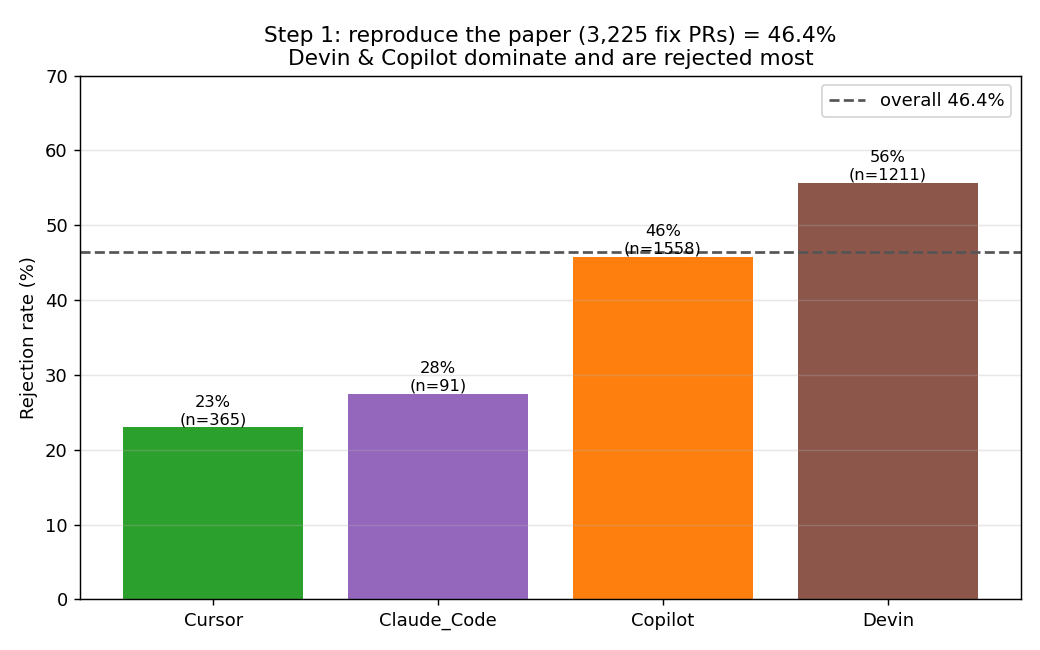

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
%matplotlib inline
pr = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet",
                     columns=["id","agent","state","merged_at","html_url"])
tt = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_task_type.parquet", columns=["id","type"])
fix_ids = set(tt[tt.type=="fix"]["id"])
paper = pr[pr.id.isin(fix_ids) & (pr.state=="closed") & (pr.agent!="OpenAI_Codex")].copy()
paper["rej"] = paper["merged_at"].isna()
print(f"paper fix PRs (closed): {len(paper):,} | rejection {100*paper.rej.mean():.1f}%")
print((100*paper.groupby("agent")["rej"].mean()).round(1).to_string())
print(paper.agent.value_counts().to_string())

## Step 2 — The decisive test: the SAME PRs in our fresh data

We take the paper's exact 3,225 PRs, match them to our dataset **by GitHub URL** (their internal ids differ from ours),
and recompute the outcome using our fresh (Feb 2026) data.

**They agree: ~48% rejected in our data too.** So the rejected ones stayed rejected — **outcomes did not change**.
That rules out collection timing, "merges landing later", project popularity, and the time window. Same PRs → same answer.

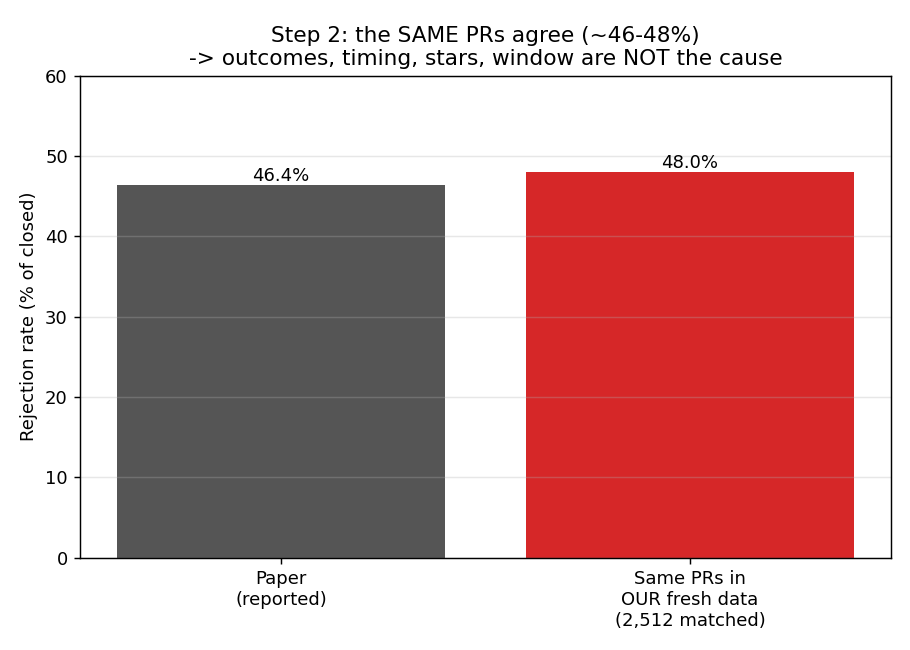

In [ ]:
our = pd.read_parquet(r"C:\Users\Mahmoudabujadallah\final_agantic_bugfixes\data\fix_prs_only.parquet",
                      columns=["html_url","state","merged_at"])
mna = our["merged_at"].isna() | our["merged_at"].astype(str).isin(["","NaT","None","nan"])
our["merged"]=~mna; our["closed"]=our["state"]=="closed"
ob = our.set_index("html_url")
found = paper["html_url"][paper["html_url"].isin(ob.index)]
sub = ob.loc[found.values]
print(f"matched {len(found):,}/{len(paper):,} of the paper's PRs by URL")
print(f"rejection on the SAME PRs in OUR data: {100*(~sub[sub.closed]['merged']).mean():.1f}%  (paper: 46.4%)")

## Step 3 — So why is our *overall* rate only ~16%?

Because our **"fix" set is far larger**. In the *same* >100-star repos and the *same* window (≤ Jul 2025), the paper's
classifier labels **3,225** fix PRs, but our `type=fix` + fresh GitHub re-collection labels **~7× more**. The extra PRs
are mostly routine fixes that merge easily, so the average rejection drops to ~16%. Our set is also later in time and
more Claude/Cursor-heavy (the better-accepted agents), which lowers it further.

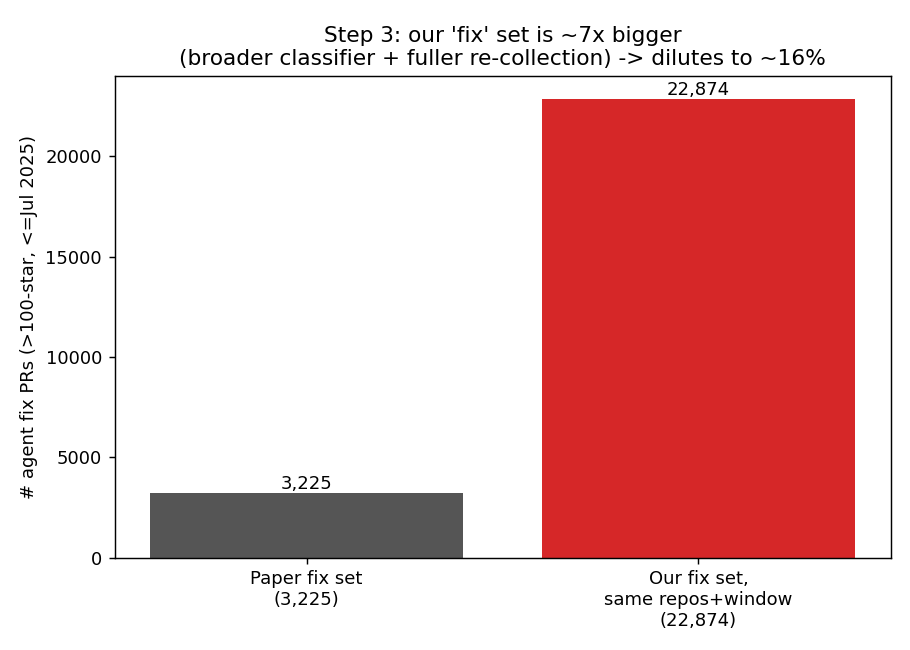

In [ ]:
ag = our.copy()  # reuse loaded 'our'? reload with needed cols for clarity
ag = pd.read_parquet(r"C:\Users\Mahmoudabujadallah\final_agantic_bugfixes\data\fix_prs_only.parquet",
                     columns=["is_agent","created_at","repo_id","state","merged_at"])
ag = ag[ag.is_agent].copy()
ag["cd"] = pd.to_datetime(ag["created_at"], utc=True, errors="coerce")
pop = set(pd.read_parquet("hf://datasets/hao-li/AIDev/repository.parquet", columns=["id"])["id"])
W = pd.Timestamp("2025-07-30", tz="UTC")
our_popwin = int((ag.repo_id.isin(pop) & (ag.cd<=W)).sum())
print(f"paper fix set (same repos+window): 3,225")
print(f"our  fix set (same repos+window): {our_popwin:,}  -> ~{our_popwin/3225:.0f}x more")
plt.figure(figsize=(7,5))
b=plt.bar(["Paper (3,225)", f"Ours ({our_popwin:,})"], [3225, our_popwin], color=["#555","#d62728"])
for bar,v in zip(b,[3225,our_popwin]): plt.text(bar.get_x()+bar.get_width()/2, v, f"{v:,}", ha="center", va="bottom")
plt.ylabel("# agent fix PRs (>100-star, <=Jul 2025)"); plt.title("Same repos & window, ~7x more 'fix' PRs")
plt.tight_layout(); plt.show()

## Take-away

| Possible cause of 16% vs 46% | Verdict |
|---|---|
| Project popularity (>100 stars) | Ruled out |
| Time window (≤ Jul 2025) | Ruled out |
| Collection timing / merges landing later | Ruled out — **same PRs give ~48% in our data too** |
| **What is labelled a "fix" (classifier + collection breadth)** | **The cause — our set is ~7× larger and easier-merging** |

**For the paper:** don't explain the difference by stars or recency. State plainly that this dataset uses a broader
`fix` classification and a fuller re-collection, so its **absolute** rejection rate is not comparable to the earlier
study (the same PRs reproduce ~46%). The contribution of this work is the **relative** comparisons — agent vs human,
over time, by bug type — which are unaffected.